# EGILEA: Hodei Sanz


# Imports


In [26]:
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Emaitzak gehienez 3 dezimalekin erakusteko
pd.options.display.float_format = "{:.3f}".format


# Datuak kargatu eta prestatu


In [27]:
def parse_experiment_name(folder_name: str) -> str:
    m = re.match(r"^emaitzak_sentiment_(.+)$", folder_name)
    return m.group(1) if m else folder_name


def load_all_metrics(root: str | Path = "emaitzak") -> pd.DataFrame:
    root = Path(root)
    pattern = root / "*" / "*" / "test" / "metrics" / "*.csv"
    files = sorted(root.glob(str(pattern.relative_to(root))))

    if not files:
        raise FileNotFoundError(
            f"Ez da metrics CSV fitxategirik aurkitu hemen: {root}. "
            "Espero den egitura: emaitzak/<esperimentua>/<shot_type>/dev/metrics/*.csv"
        )

    rows = []

    for fp in files:
        experiment_folder = fp.parts[1]
        shot_type = fp.parts[2]
        split = fp.parts[3]
        model = fp.stem
        # Izen okerra kargatzean bertan normalizatzen da.
        # Latxa3.1-70B-FP8 fitxategia Latxa3.1-70B-v2 gisa erabiliko da analisi osoan.
        if re.fullmatch(r"latxa3\.1-70b-fp8", model, flags=re.IGNORECASE):
            model = "Latxa3.1-70B-v2"

        df_file = pd.read_csv(fp)

        df_file.insert(0, "shot_type", shot_type)
        df_file.insert(0, "split", split)
        df_file.insert(0, "model", model)
        df_file.insert(0, "experiment", parse_experiment_name(experiment_folder))

        rows.append(df_file)

    df_out = pd.concat(rows, ignore_index=True)
    df_out["Froga"] = pd.to_numeric(df_out["Froga"], errors="coerce")
    return df_out


# Datuak kargatu
df = load_all_metrics("emaitzak")

# Accuracy zutabearen izena automatikoki bilatzen da
possible_accuracy_cols = ["Accuracy", "accuracy", "ACC", "acc", "Accuracy_score", "accuracy_score"]
ACCURACY_COL = next((c for c in possible_accuracy_cols if c in df.columns), None)

if ACCURACY_COL is None:
    raise KeyError(
        "Ez da accuracy zutaberik aurkitu. "
        f"Bilatutako izenak: {possible_accuracy_cols}. "
        f"Dauden zutabeak: {list(df.columns)}"
    )

# Analisi nagusitik Froga == 2 eta GLOBAL promptak kentzen dira
df_clean = df.copy()
df_clean = df_clean[df_clean["Froga"] != 2].copy()
df_clean = df_clean[df_clean["Prompt"].astype(str).str.upper() != "GLOBAL"].copy()
df_clean["Prompt"] = pd.to_numeric(df_clean["Prompt"], errors="coerce")

# df_opt izena mantentzen da aurreko analisiekiko bateragarritasunerako
df_opt = df_clean.copy()

print(f"Erabilitako accuracy zutabea: {ACCURACY_COL}")
print(f"Hasierako errenkadak: {len(df)}")
print(f"Iragazi ondorengo errenkadak: {len(df_clean)}")
display(df_clean.head())


Erabilitako accuracy zutabea: Accuracy
Hasierako errenkadak: 3908
Iragazi ondorengo errenkadak: 2295


,experiment,model,split,shot_type,Froga,Prompt,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted,Avg_exec_time
0,v1_SysPromptBerria1,Latxa3.1-70B-v2,test,few-shot-1,1,1,0.722,0.814,0.667,0.678,0.780,0.722,0.700,0.181
1,v1_SysPromptBerria1,Latxa3.1-70B-v2,test,few-shot-1,1,2,0.712,0.817,0.653,0.668,0.780,0.712,0.689,0.179
2,v1_SysPromptBerria1,Latxa3.1-70B-v2,test,few-shot-1,1,3,0.722,0.814,0.666,0.676,0.781,0.722,0.698,0.179
4,v1_SysPromptBerria1,Latxa3.1-70B-v2,test,few-shot-1,3,1,0.749,0.784,0.711,0.721,0.768,0.749,0.737,0.172
5,v1_SysPromptBerria1,Latxa3.1-70B-v2,test,few-shot-1,3,2,0.742,0.824,0.694,0.703,0.793,0.742,0.723,0.176


# Funtzioak


In [28]:
# =========================
# Formateatzeko eta laburtzeko funtzio orokorrak
# =========================

def round_numeric(df_in: pd.DataFrame, ndigits: int = 3) -> pd.DataFrame:
    """Zenbakizko zutabeak gehienez 3 dezimalekin uzteko funtzio lagungarria."""
    out = df_in.copy()
    num_cols = out.select_dtypes(include="number").columns
    out[num_cols] = out[num_cols].round(ndigits)
    return out


def first_existing_col(df_in: pd.DataFrame, candidates: list[str]):
    """Zerrendako lehen zutabe erabilgarria itzultzen du."""
    for c in candidates:
        if c in df_in.columns:
            return c
    return None


def safe_display_cols(df_in: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Dauden zutabeak bakarrik erakusteko."""
    existing = [c for c in cols if c in df_in.columns]
    return round_numeric(df_in[existing])


def summarize_config(df_in: pd.DataFrame, group_cols, metric_col: str = None) -> pd.DataFrame:
    """
    Talde bakoitzerako accuracy, denbora eta egonkortasun-neurriak kalkulatzen ditu.
    Ordena nagusia: accuracy handiena; berdinketetan, denbora txikiena.
    """
    metric_col = metric_col or ACCURACY_COL

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out = (
        df_in
        .groupby(group_cols, dropna=False, as_index=False)
        .agg(
            mean_accuracy=(metric_col, "mean"),
            std_accuracy=(metric_col, "std"),
            min_accuracy=(metric_col, "min"),
            max_accuracy=(metric_col, "max"),
            mean_time=("Avg_exec_time", "mean"),
            std_time=("Avg_exec_time", "std"),
            n_runs=(metric_col, "count")
        )
    )

    out["std_accuracy"] = out["std_accuracy"].fillna(0)
    out["std_time"] = out["std_time"].fillna(0)

    # Egonkortasun-score sinplea: accuracy altua eta aldakortasun txikia saritzeko.
    out["stability_score"] = out["mean_accuracy"] - out["std_accuracy"]

    # Eraginkortasun-score sinplea: accuracy / denbora.
    out["efficiency_score"] = np.where(
        out["mean_time"] > 0,
        out["mean_accuracy"] / out["mean_time"],
        np.nan
    )

    out = out.sort_values(
        ["mean_accuracy", "mean_time", "std_accuracy"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    return round_numeric(out)


def summarize_by(df_in: pd.DataFrame, group_cols, metric_col: str = None) -> pd.DataFrame:
    """Accuracy eta exekuzio-denboraren laburpena sortzen du."""
    metric_col = metric_col or ACCURACY_COL

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out = (
        df_in
        .groupby(group_cols, dropna=False, as_index=False)
        .agg(
            mean_accuracy=(metric_col, "mean"),
            std_accuracy=(metric_col, "std"),
            mean_time=("Avg_exec_time", "mean"),
            std_time=("Avg_exec_time", "std"),
            n_runs=(metric_col, "count")
        )
        .sort_values(["mean_accuracy", "mean_time"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return round_numeric(out)


# =========================
# Modeloen metadatuak
# =========================

def normalize_model_name(model_name: str) -> str:
    """
    Modelo-izenak bistaratze koherenterako normalizatzen ditu.
    Latxa3.1-70B-FP8 modeloa Latxa3.1-70B-v2 gisa erakusten da.
    """
    name = str(model_name).strip()
    if re.fullmatch(r"latxa3\.1-70b-fp8", name, flags=re.IGNORECASE):
        return "Latxa3.1-70B-v2"
    return name


def infer_model_family(model_name: str) -> str:
    """Modeloaren familia inferitzen du izenetik."""
    name = normalize_model_name(model_name).lower()
    if "latxa" in name:
        return "Latxa"
    if "llama" in name:
        return "Llama"
    if "salamandra" in name:
        return "Salamandra"
    return "Bestelakoa"


def canonicalize_model_base(model_name: str) -> str:
    """
    Base-izena modu bateratuan idazten du.

    Lan honetako irizpidea:
    - `-fp16` dutenak ez kuantizatutako bertsio gisa hartzen dira.
    - `Latxa3.1-70B-v2` `Latxa3.1-70B` basearen bertsio kuantizatua da.
    """
    base = normalize_model_name(model_name)
    base = re.sub(r"-(?:fp16|fp8|v2)$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"^latxa", "Latxa", base, flags=re.IGNORECASE)
    base = re.sub(r"^llama", "Llama", base, flags=re.IGNORECASE)
    base = re.sub(r"^salamandra", "Salamandra", base, flags=re.IGNORECASE)
    return base


def infer_model_size_b(model_name: str):
    """Modeloaren parametro kopurua inferitzen du, B unitatean."""
    name = normalize_model_name(model_name).lower()
    m = re.search(r"(\d+(?:\.\d+)?)\s*b", name)
    if m:
        return float(m.group(1))
    return np.nan


def infer_model_size_group(size_b) -> str:
    """Tamainaren arabera, modeloa txikia edo handia den sailkatzen du."""
    if pd.isna(size_b):
        return "ezezaguna"
    if size_b >= 70:
        return "handia"
    if size_b <= 10:
        return "txikia"
    return "ertaina"


def infer_quantization_type(model_name: str) -> str:
    """
    Kuantizazio-etiketa inferitzen du.

    Lan honetako irizpidea:
    - `-fp16` duten modeloak ez kuantizatutako bertsioak dira.
      Kasu honetan, FP16k FullyProcessed in 16 bits esan nahi du.
    - Gainerako modeloak kuantizatutzat hartzen dira.
    - `Latxa3.1-70B-FP8` izen okerra `Latxa3.1-70B-v2` gisa normalizatzen da,
      eta kuantizatu gisa sailkatzen da.
    """
    name = normalize_model_name(model_name).strip()
    if re.search(r"-fp16$", name, flags=re.IGNORECASE):
        return "ez kuantizatua"
    return "kuantizatua"


def is_quantized_model(model_name: str) -> bool:
    """Modelo bat kuantizatua den ala ez adierazten du."""
    name = normalize_model_name(model_name).strip()
    return not bool(re.search(r"-fp16$", name, flags=re.IGNORECASE))


def add_model_metadata(df_in: pd.DataFrame) -> pd.DataFrame:
    """df bati modelo-familia, tamaina eta kuantizazioari buruzko zutabeak gehitzen dizkio."""
    out = df_in.copy()
    out["model_original"] = out["model"].astype(str)
    out["model"] = out["model"].apply(normalize_model_name)
    out["model_base"] = out["model"].apply(canonicalize_model_base)
    out["model_family"] = out["model"].apply(infer_model_family)
    out["model_size_b"] = out["model"].apply(infer_model_size_b)
    out["model_size_group"] = out["model_size_b"].apply(infer_model_size_group)
    out["quantization_type"] = out["model"].apply(infer_quantization_type)
    out["is_quantized"] = out["model"].apply(is_quantized_model)
    out["quantization"] = np.where(out["is_quantized"], "kuantizatua", "ez kuantizatua")
    return out


# =========================
# Precision, recall eta accuracy-rako funtzioak
# =========================

def plot_grouped_hbar(
    df_sum,
    title,
    x_label,
    col_macro,
    col_weighted,
    label_macro="Macro",
    label_weighted="Weighted",
    top_n=None
):
    d = df_sum.copy()
    if top_n is not None:
        d = d.head(top_n)

    models = d["model"].astype(str).tolist()
    y = np.arange(len(models))
    h = 0.38

    macro_vals = d[col_macro].to_numpy()
    weighted_vals = d[col_weighted].to_numpy()

    max_val = max(macro_vals.max(), weighted_vals.max())

    plt.figure()
    plt.barh(y - h / 2, macro_vals, height=h, label=label_macro)
    plt.barh(y + h / 2, weighted_vals, height=h, label=label_weighted)

    offset = max_val * 0.01

    for i, v in enumerate(macro_vals):
        plt.text(v + offset, y[i] - h / 2, f"{v:.3f}", va="center")

    for i, v in enumerate(weighted_vals):
        plt.text(v + offset, y[i] + h / 2, f"{v:.3f}", va="center")

    plt.xlim(0, max_val * 1.10)
    plt.yticks(y, models)
    plt.gca().invert_yaxis()
    plt.xlabel(x_label)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def _infer_full_metric_col(summary_col, df_full):
    """
    Summary zutabeetatik jatorrizko dataframe-ko metrika zutabea inferitzen du.
    Adibidez:
      precision_macro -> Precision_macro
      mean_recall_weighted -> Recall_weighted
    """
    candidates = [
        summary_col,
        summary_col.replace("_mean", ""),
        summary_col.replace("mean_", ""),
        summary_col.replace("std_", ""),
    ]

    more_candidates = []
    for c in candidates:
        more_candidates.extend([
            c,
            c[:1].upper() + c[1:],
            c.replace("precision", "Precision"),
            c.replace("recall", "Recall"),
            c.replace("accuracy", "Accuracy"),
        ])

    for c in more_candidates:
        if c in df_full.columns:
            return c

    return None


def best_models_from_summary(df_sum, macro_col, weighted_col, label, df_full):
    """Precision/recall laburpenetatik eredu onenak eta max/min absolutuak inprimatzen ditu."""
    best_macro = df_sum.loc[df_sum[macro_col].idxmax(), ["model", macro_col]]
    best_weighted = df_sum.loc[df_sum[weighted_col].idxmax(), ["model", weighted_col]]

    print(f"=== BEST {label} (by mean) ===")
    print(f"Best (Macro):    {best_macro['model']}  -> {best_macro[macro_col]:.3f}")
    print(f"Best (Weighted): {best_weighted['model']}  -> {best_weighted[weighted_col]:.3f}")
    print()

    full_macro_col = _infer_full_metric_col(macro_col, df_full)
    full_weighted_col = _infer_full_metric_col(weighted_col, df_full)

    if full_macro_col is None or full_weighted_col is None:
        print("Ezin izan dira jatorrizko metrika zutabeak inferitu max/min absolutuak kalkulatzeko.")
        return

    max_macro_row = df_full.loc[df_full[full_macro_col].idxmax()]
    min_macro_row = df_full.loc[df_full[full_macro_col].idxmin()]
    max_weighted_row = df_full.loc[df_full[full_weighted_col].idxmax()]
    min_weighted_row = df_full.loc[df_full[full_weighted_col].idxmin()]

    print("=== ABSOLUTE VALUES (ALL DATA) ===\n")

    print(f"Max {full_macro_col}:")
    print(f"Value: {max_macro_row[full_macro_col]:.3f}")
    print(f"Model: {max_macro_row['model']} | Froga: {max_macro_row['Froga']} | Prompt: {max_macro_row['Prompt']}")
    print()

    print(f"Min {full_macro_col}:")
    print(f"Value: {min_macro_row[full_macro_col]:.3f}")
    print(f"Model: {min_macro_row['model']} | Froga: {min_macro_row['Froga']} | Prompt: {min_macro_row['Prompt']}")
    print()

    print(f"Max {full_weighted_col}:")
    print(f"Value: {max_weighted_row[full_weighted_col]:.3f}")
    print(f"Model: {max_weighted_row['model']} | Froga: {max_weighted_row['Froga']} | Prompt: {max_weighted_row['Prompt']}")
    print()

    print(f"Min {full_weighted_col}:")
    print(f"Value: {min_weighted_row[full_weighted_col]:.3f}")
    print(f"Model: {min_weighted_row['model']} | Froga: {min_weighted_row['Froga']} | Prompt: {min_weighted_row['Prompt']}")
    print()


def best_models_single_metric(df_in, metric_col, label, group_col="model"):
    """Metrika bakar baterako ranking eta max/min absolutuak."""
    summary = (
        df_in
        .groupby(group_col, as_index=False)
        .agg(
            mean_metric=(metric_col, "mean"),
            std_metric=(metric_col, "std"),
            n=(metric_col, "count")
        )
        .sort_values("mean_metric", ascending=False)
        .reset_index(drop=True)
    )

    best_mean = summary.loc[summary["mean_metric"].idxmax()]
    max_row = df_in.loc[df_in[metric_col].idxmax()]
    min_row = df_in.loc[df_in[metric_col].idxmin()]

    print(f"=== BEST {label} (by mean) ===")
    print(f"Best {group_col}: {best_mean[group_col]} -> {best_mean['mean_metric']:.3f}")
    print()

    print("=== ABSOLUTE VALUES (ALL DATA) ===\n")
    print(f"Max {label}:")
    print(f"Value: {max_row[metric_col]:.3f}")
    print(f"Model: {max_row['model']} | Froga: {max_row['Froga']} | Prompt: {max_row['Prompt']}")
    print()

    print(f"Min {label}:")
    print(f"Value: {min_row[metric_col]:.3f}")
    print(f"Model: {min_row['model']} | Froga: {min_row['Froga']} | Prompt: {min_row['Prompt']}")

    return round_numeric(summary)


def build_pivot_model_froga(df_in, value_col):
    pivot = (
        df_in
        .groupby(["model", "Froga"], as_index=False)[value_col]
        .mean()
        .pivot(index="model", columns="Froga", values=value_col)
    )
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    return round_numeric(pivot)


def build_pivot_model_shot(df_in, value_col):
    pivot = (
        df_in
        .groupby(["model", "shot_type"], as_index=False)[value_col]
        .mean()
        .pivot(index="model", columns="shot_type", values=value_col)
    )

    preferred_cols = ["zero-shot", "few-shot-1", "few-shot-2"]
    cols = [c for c in preferred_cols if c in pivot.columns] + [
        c for c in pivot.columns if c not in preferred_cols
    ]
    pivot = pivot[cols]
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    return round_numeric(pivot)


# =========================
# Paretoak eta grafikoak
# =========================

def pareto_mask(df_in: pd.DataFrame, time_col: str, quality_col: str) -> np.ndarray:
    """
    Pareto frontier-erako maskara.
    Minimizatu: time_col
    Maximizatu: quality_col
    """
    x = df_in[time_col].to_numpy()
    y = df_in[quality_col].to_numpy()
    n = len(df_in)

    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        dominates_i = (x <= x[i]) & (y >= y[i]) & ((x < x[i]) | (y > y[i]))
        dominates_i[i] = False
        if np.any(dominates_i):
            is_pareto[i] = False

    return is_pareto


def make_group_summary(df_in: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Taldearen eta modeloaren araberako accuracy/denbora laburpena."""
    out = (
        df_in
        .groupby([group_col, "model"], as_index=False)
        .agg(
            mean_time=("Avg_exec_time", "mean"),
            mean_accuracy=(ACCURACY_COL, "mean"),
            n_runs=("Avg_exec_time", "count")
        )
    )
    return round_numeric(out)


def plot_all_groups_with_pareto(
    summary_df: pd.DataFrame,
    group_col: str,
    quality_col: str,
    title: str,
    label_pareto: bool = True
):
    """Puntu guztiak eta Pareto puntuak grafiko bakarrean erakusten ditu."""
    dfp = summary_df.dropna(subset=["mean_time", quality_col]).copy()

    mask = pareto_mask(dfp, time_col="mean_time", quality_col=quality_col)
    pareto_pts = dfp[mask]
    other_pts = dfp[~mask]

    plt.figure()
    plt.scatter(other_pts["mean_time"], other_pts[quality_col])
    plt.scatter(pareto_pts["mean_time"], pareto_pts[quality_col])

    if label_pareto:
        for _, r in pareto_pts.iterrows():
            plt.text(
                r["mean_time"],
                r[quality_col],
                f'{r["model"]} | {group_col}={r[group_col]}'
            )

    plt.xlabel("Mean execution time (s)")
    plt.ylabel(quality_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return round_numeric(dfp), round_numeric(pareto_pts)


def pareto_frontier_2d_all_points(df_in: pd.DataFrame, time_col: str, quality_col: str) -> pd.DataFrame:
    """
    Puntu guztietarako Pareto frontier-a.
    Minimizatu: time_col
    Maximizatu: quality_col
    """
    d = df_in.dropna(subset=[time_col, quality_col]).copy()
    d = d.sort_values([time_col, quality_col], ascending=[True, False]).reset_index(drop=True)

    best_q = -np.inf
    keep = np.zeros(len(d), dtype=bool)

    for i, q in enumerate(d[quality_col].to_numpy()):
        if q > best_q:
            keep[i] = True
            best_q = q

    return round_numeric(d[keep].copy())


def plot_all_points_with_pareto(
    df_in: pd.DataFrame,
    pareto_df: pd.DataFrame,
    time_col: str,
    quality_col: str,
    title: str
):
    """Puntu guztiak eta Pareto puntuak erakusten ditu."""
    plt.figure()
    plt.scatter(df_in[time_col], df_in[quality_col])
    plt.scatter(pareto_df[time_col], pareto_df[quality_col])
    plt.xlabel(time_col)
    plt.ylabel(quality_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================
# Konparazio espezifikoak
# =========================

def build_quantization_pair_effect(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    Kuantizatutako aldaera bakoitza bere base kuantizatu gabearekin alderatzen du.
    Base berak kuantizatutako aldaera bat baino gehiago baditu, guztiak bereizita agertzen dira.
    """
    rows = []
    means = (
        df_in
        .groupby(
            ["model_base", "model_family", "model_size_group", "model", "quantization_type", "is_quantized"],
            as_index=False
        )
        .agg(
            mean_accuracy=(ACCURACY_COL, "mean"),
            mean_time=("Avg_exec_time", "mean"),
            n_runs=(ACCURACY_COL, "count")
        )
    )

    for (base, family, size_group), g in means.groupby(["model_base", "model_family", "model_size_group"]):
        nq = g[~g["is_quantized"]]
        q_variants = g[g["is_quantized"]]
        if len(nq) == 0 or len(q_variants) == 0:
            continue

        nq = nq.sort_values("model").iloc[0]
        for _, q in q_variants.sort_values(["quantization_type", "model"]).iterrows():
            rows.append({
                "model_base": base,
                "model_kuantizatua": q["model"],
                "kuantizazio_mota": q["quantization_type"],
                "model_ez kuantizatua": nq["model"],
                "model_family": family,
                "model_size_group": size_group,
                "accuracy_kuantizatua": q["mean_accuracy"],
                "accuracy_ez kuantizatua": nq["mean_accuracy"],
                "accuracy_diff_kuantizatua_minus_gabea": q["mean_accuracy"] - nq["mean_accuracy"],
                "time_kuantizatua": q["mean_time"],
                "time_ez kuantizatua": nq["mean_time"],
                "time_diff_kuantizatua_minus_gabea": q["mean_time"] - nq["mean_time"],
                "n_runs_kuantizatua": q["n_runs"],
                "n_runs_ez kuantizatua": nq["n_runs"]
            })

    return round_numeric(pd.DataFrame(rows))


def infer_basque_specific_group(family: str) -> str:
    """Euskara esplizituki landu duten ereduen taldea inferitzeko."""
    if family in ["Latxa", "Salamandra"]:
        return "euskara_esplizitua"
    if family == "Llama":
        return "eredu_orokorra"
    return "bestelakoa"


def normalize_shot_group(shot_type) -> str:
    """Zero-shot eta few-shot multzo nagusiak sortzeko."""
    s = str(shot_type).lower()
    if "zero" in s:
        return "zero-shot"
    if "few" in s:
        return "few-shot"
    return "bestelakoa"


def infer_v1_v2_from_row(row, version_source_cols: list[str]) -> str:
    """Errenkada batean v1/v2 informazioa bilatzen du."""
    text = " ".join(str(row[c]) for c in version_source_cols if pd.notna(row[c]))

    patterns = [
        r"(?i)(?:^|[_\-\s])v\s*([12])(?:$|[_\-\s])",
        r"(?i)(?:version|bertsio|bertsioa)[_\-\s]*([12])",
        r"(?i)(?:^|[_\-\s])([12])(?:$|[_\-\s])"
    ]

    for pat in patterns:
        m = re.search(pat, text)
        if m:
            return f"v{m.group(1)}"

    return "ez_identifikatua"


def print_best_from_summary(name: str, df_sum: pd.DataFrame, label_col: str):
    """Laburpen-taula batetik accuracy altuena eta egonkorrena inprimatzen ditu."""
    if df_sum.empty:
        print(f"{name}: ez dago daturik.")
        return

    r_acc = df_sum.sort_values(["mean_accuracy", "mean_time"], ascending=[False, True]).iloc[0]
    r_stable = df_sum.sort_values(["stability_score", "mean_accuracy"], ascending=[False, False]).iloc[0]

    print(f"{name}")
    print(
        f"  Accuracy altuena: {r_acc[label_col]} | "
        f"mean_accuracy={r_acc['mean_accuracy']:.3f} | "
        f"mean_time={r_acc['mean_time']:.3f}"
    )
    print(
        f"  Egonkorrena: {r_stable[label_col]} | "
        f"stability_score={r_stable['stability_score']:.3f} | "
        f"std_accuracy={r_stable['std_accuracy']:.3f}"
    )


def detect_outliers_iqr(series):
    """IQR bidez outlierren mugak kalkulatzen ditu."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper


# Datu eratorriak sortu

Bloke honetan analisirako erabiliko diren taula nagusiak sortzen dira: modeloen metadatuak, system promptaren zutabe normalizatua eta erabiliko diren aldagai osagarriak.


In [29]:
# Modeloen metadatuak gehitu
df_model = add_model_metadata(df_opt)

# Analisi nagusirako dataframe-a
df_analysis = df_model.copy()

# System prompt zutabea automatikoki bilatzen da. Ez badago, experiment erabiltzen da.
system_prompt_source_col = first_existing_col(
    df_analysis,
    [
        "system_prompt", "System_prompt", "SYSTEM_PROMPT",
        "system_prompt_id", "system_prompt_name",
        "system_prompt_type", "prompt_system",
        "experiment"
    ]
)

if system_prompt_source_col is None:
    df_analysis["system_prompt"] = "ez_identifikatua"
else:
    df_analysis["system_prompt"] = df_analysis[system_prompt_source_col].astype(str)

# Euskararen eragina eta shot taldeak aurrez kalkulatuta uzten dira
df_analysis["euskararen_eragina_taldea"] = df_analysis["model_family"].apply(infer_basque_specific_group)
df_analysis["shot_group"] = df_analysis["shot_type"].apply(normalize_shot_group)

model_metadata_cols = [
    "model_original", "model", "model_base", "model_family", "model_size_b",
    "model_size_group", "quantization", "quantization_type"
]
model_metadata_cols = [c for c in model_metadata_cols if c in df_model.columns]

model_metadata = (
    df_model[model_metadata_cols]
    .drop_duplicates()
    .sort_values(["model_family", "model_size_b", "quantization", "quantization_type", "model"])
    .reset_index(drop=True)
)

print(f"System prompt gisa erabilitako zutabea: {system_prompt_source_col}")
print(f"Analizatutako errenkadak: {len(df_analysis)}")
display(model_metadata)


System prompt gisa erabilitako zutabea: experiment
Analizatutako errenkadak: 2295


,model_original,model,model_base,model_family,model_size_b,model_size_group,quantization,quantization_type
0,latxa3.1-8B-fp16,latxa3.1-8B-fp16,Latxa3.1-8B,Latxa,8.000,txikia,ez kuantizatua,ez kuantizatua
1,latxa3.1-8B,latxa3.1-8B,Latxa3.1-8B,Latxa,8.000,txikia,kuantizatua,kuantizatua
2,Latxa3.1-70B-v2,Latxa3.1-70B-v2,Latxa3.1-70B,Latxa,70.000,handia,kuantizatua,kuantizatua
3,latxa3.1-70B,latxa3.1-70B,Latxa3.1-70B,Latxa,70.000,handia,kuantizatua,kuantizatua
4,llama3.1-8B-fp16,llama3.1-8B-fp16,Llama3.1-8B,Llama,8.000,txikia,ez kuantizatua,ez kuantizatua
5,llama3.1-8B,llama3.1-8B,Llama3.1-8B,Llama,8.000,txikia,kuantizatua,kuantizatua
6,llama3.1-70B,llama3.1-70B,Llama3.1-70B,Llama,70.000,handia,kuantizatua,kuantizatua
7,salamandra-7B,salamandra-7B,Salamandra-7B,Salamandra,7.000,txikia,kuantizatua,kuantizatua


# Precision eta recall

Atal hau bigarren mailako metrikak aztertzeko da. Notebook-ean atal oso hau tolestu/itxi daiteke, analisi nagusia `accuracy` metrikaren inguruan kontzentratzeko.


## Precision


Precision: modeloen batezbestekoak


,model,precision_macro,precision_weighted,std_precision_macro,std_precision_weighted,n_runs
0,Latxa3.1-70B-v2,0.817,0.782,0.018,0.015,270
1,latxa3.1-8B-fp16,0.745,0.755,0.028,0.028,270
2,salamandra-7B,0.659,0.655,0.094,0.091,297
3,latxa3.1-8B,0.622,0.632,0.160,0.184,297
4,llama3.1-8B-fp16,0.617,0.617,0.111,0.100,270
5,llama3.1-70B,0.606,0.597,0.138,0.117,297
6,llama3.1-8B,0.572,0.566,0.144,0.132,297
7,latxa3.1-70B,0.449,0.463,0.233,0.206,297


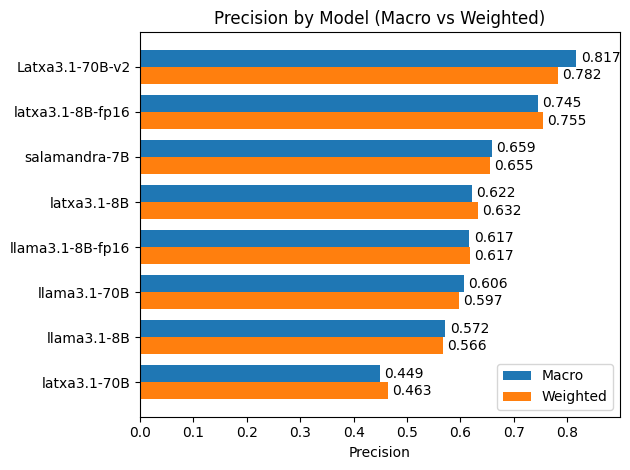

=== BEST PRECISION (by mean) ===
Best (Macro):    Latxa3.1-70B-v2  -> 0.817
Best (Weighted): Latxa3.1-70B-v2  -> 0.782

=== ABSOLUTE VALUES (ALL DATA) ===

Max Precision_macro:
Value: 0.852
Model: Latxa3.1-70B-v2 | Froga: 3 | Prompt: 3

Min Precision_macro:
Value: 0.084
Model: latxa3.1-8B | Froga: 4 | Prompt: 2

Max Precision_weighted:
Value: 0.827
Model: latxa3.1-8B-fp16 | Froga: 4 | Prompt: 3

Min Precision_weighted:
Value: 0.063
Model: latxa3.1-8B | Froga: 4 | Prompt: 2



In [30]:
precision_sum = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        precision_macro=("Precision_macro", "mean"),
        precision_weighted=("Precision_weighted", "mean"),
        std_precision_macro=("Precision_macro", "std"),
        std_precision_weighted=("Precision_weighted", "std"),
        n_runs=("Precision_macro", "count")
    )
    .sort_values("precision_macro", ascending=False)
    .reset_index(drop=True)
)

print("Precision: modeloen batezbestekoak")
display(round_numeric(precision_sum))

plot_grouped_hbar(
    precision_sum,
    title="Precision by Model (Macro vs Weighted)",
    x_label="Precision",
    col_macro="precision_macro",
    col_weighted="precision_weighted"
)

best_models_from_summary(precision_sum, "precision_macro", "precision_weighted", "PRECISION", df_clean)


## Recall


Recall: modeloen batezbestekoak


,model,recall_macro,recall_weighted,std_recall_macro,std_recall_weighted,n_runs
0,latxa3.1-8B-fp16,0.708,0.707,0.051,0.060,270
1,Latxa3.1-70B-v2,0.655,0.714,0.041,0.030,270
2,salamandra-7B,0.619,0.616,0.083,0.095,297
3,latxa3.1-8B,0.558,0.513,0.119,0.156,297
4,llama3.1-8B-fp16,0.512,0.550,0.089,0.059,270
5,llama3.1-70B,0.492,0.563,0.099,0.077,297
6,llama3.1-8B,0.464,0.514,0.087,0.081,297
7,latxa3.1-70B,0.440,0.516,0.137,0.122,297


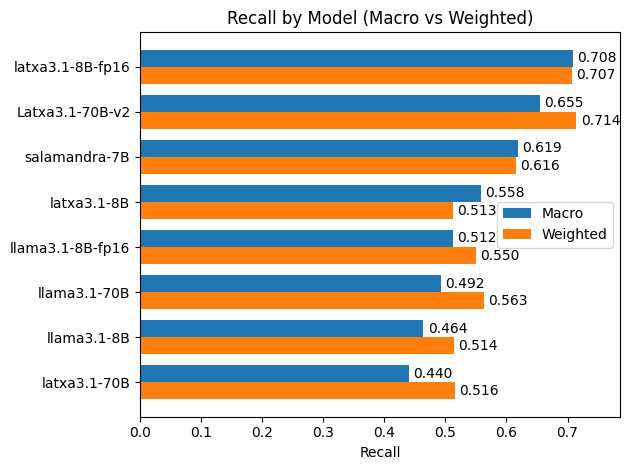

=== BEST RECALL (by mean) ===
Best (Macro):    latxa3.1-8B-fp16  -> 0.708
Best (Weighted): Latxa3.1-70B-v2  -> 0.714

=== ABSOLUTE VALUES (ALL DATA) ===

Max Recall_macro:
Value: 0.818
Model: latxa3.1-8B-fp16 | Froga: 4 | Prompt: 3

Min Recall_macro:
Value: 0.239
Model: latxa3.1-70B | Froga: 4 | Prompt: 2

Max Recall_weighted:
Value: 0.816
Model: latxa3.1-8B-fp16 | Froga: 4 | Prompt: 3

Min Recall_weighted:
Value: 0.251
Model: latxa3.1-8B | Froga: 4 | Prompt: 2



In [31]:
recall_sum = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        recall_macro=("Recall_macro", "mean"),
        recall_weighted=("Recall_weighted", "mean"),
        std_recall_macro=("Recall_macro", "std"),
        std_recall_weighted=("Recall_weighted", "std"),
        n_runs=("Recall_macro", "count")
    )
    .sort_values("recall_macro", ascending=False)
    .reset_index(drop=True)
)

print("Recall: modeloen batezbestekoak")
display(round_numeric(recall_sum))

plot_grouped_hbar(
    recall_sum,
    title="Recall by Model (Macro vs Weighted)",
    x_label="Recall",
    col_macro="recall_macro",
    col_weighted="recall_weighted"
)

best_models_from_summary(recall_sum, "recall_macro", "recall_weighted", "RECALL", df_clean)


# Accuracy: analisi nagusia

Atal honetan daude emaitza nagusiak. Metrika nagusia `accuracy` da, eta bigarren irizpide gisa `Avg_exec_time` erabiltzen da.


## 1. Laburpen orokorra: modeloen accuracy eta denbora


In [32]:
accuracy_summary = best_models_single_metric(
    df_in=df_analysis,
    metric_col=ACCURACY_COL,
    label="Accuracy",
    group_col="model"
)

model_overall_summary = summarize_config(
    df_analysis,
    ["model", "model_family", "model_size_group", "quantization", "quantization_type"]
)

ranking_time_general = (
    df_analysis
    .groupby("model", as_index=False)
    .agg(
        mean_time=("Avg_exec_time", "mean"),
        std_time=("Avg_exec_time", "std"),
        n_runs=("Avg_exec_time", "count")
    )
    .sort_values("mean_time", ascending=True)
    .reset_index(drop=True)
)

print("Modeloen ranking orokorra accuracy-ren arabera:")
display(model_overall_summary)

print("Modeloen ranking orokorra denboraren arabera:")
display(round_numeric(ranking_time_general))


=== BEST Accuracy (by mean) ===
Best model: Latxa3.1-70B-v2 -> 0.714

=== ABSOLUTE VALUES (ALL DATA) ===

Max Accuracy:
Value: 0.816
Model: latxa3.1-8B-fp16 | Froga: 4 | Prompt: 3

Min Accuracy:
Value: 0.251
Model: latxa3.1-8B | Froga: 4 | Prompt: 2
Modeloen ranking orokorra accuracy-ren arabera:


,model,model_family,model_size_group,quantization,quantization_type,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,Latxa3.1-70B-v2,Latxa,handia,kuantizatua,kuantizatua,0.714,0.030,0.645,0.786,0.174,0.007,270,0.685,4.097
1,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,0.707,0.060,0.452,0.816,0.116,0.026,270,0.647,6.110
2,salamandra-7B,Salamandra,txikia,kuantizatua,kuantizatua,0.616,0.095,0.298,0.758,0.164,0.178,297,0.520,3.749
3,llama3.1-70B,Llama,handia,kuantizatua,kuantizatua,0.563,0.077,0.365,0.754,1.019,0.354,297,0.486,0.552
4,llama3.1-8B-fp16,Llama,txikia,ez kuantizatua,ez kuantizatua,0.550,0.059,0.301,0.709,0.119,0.029,270,0.491,4.639
5,latxa3.1-70B,Latxa,handia,kuantizatua,kuantizatua,0.516,0.122,0.271,0.756,1.262,0.492,297,0.393,0.409
6,llama3.1-8B,Llama,txikia,kuantizatua,kuantizatua,0.514,0.081,0.291,0.669,0.213,0.175,297,0.433,2.410
7,latxa3.1-8B,Latxa,txikia,kuantizatua,kuantizatua,0.513,0.156,0.251,0.776,0.148,0.085,297,0.357,3.472


Modeloen ranking orokorra denboraren arabera:


,model,mean_time,std_time,n_runs
0,latxa3.1-8B-fp16,0.116,0.026,270
1,llama3.1-8B-fp16,0.119,0.029,270
2,latxa3.1-8B,0.148,0.085,297
3,salamandra-7B,0.164,0.178,297
4,Latxa3.1-70B-v2,0.174,0.007,270
5,llama3.1-8B,0.213,0.175,297
6,llama3.1-70B,1.019,0.354,297
7,latxa3.1-70B,1.262,0.492,297


## 2. Konbinazio onena


In [33]:
combination_cols = [
    "system_prompt",
    "model",
    "model_family",
    "model_size_group",
    "quantization",
    "quantization_type",
    "shot_type",
    "Froga",
    "Prompt"
]
combination_cols = [c for c in combination_cols if c in df_analysis.columns]

combination_summary = summarize_config(df_analysis, combination_cols)

print("Accuracy handieneko konbinazioa:")
display(combination_summary.head(1))

print("Top 20 konbinazioak accuracy-ren arabera:")
display(combination_summary.head(20))

print("Top 20 konbinazio egonkorrenak (mean_accuracy - std_accuracy):")
display(
    combination_summary
    .sort_values(["stability_score", "mean_accuracy", "mean_time"], ascending=[False, False, True])
    .head(20)
)

print("Top 20 konbinazio eraginkorrenak (accuracy / denbora):")
display(
    combination_summary
    .sort_values(["efficiency_score", "mean_accuracy"], ascending=[False, False])
    .head(20)
)


Accuracy handieneko konbinazioa:


,system_prompt,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,4,3,0.816,0.000,0.816,0.816,0.093,0.000,1,0.816,8.785


Top 20 konbinazioak accuracy-ren arabera:


,system_prompt,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,4,3,0.816,0.000,0.816,0.816,0.093,0.000,1,0.816,8.785
1,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-2,4,3,0.813,0.000,0.813,0.813,0.110,0.000,1,0.813,7.384
2,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-2,1,2,0.811,0.000,0.811,0.811,0.091,0.000,1,0.811,8.892
3,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,3,0.801,0.000,0.801,0.801,0.087,0.000,1,0.801,9.210
4,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,3,0.794,0.000,0.794,0.794,0.085,0.000,1,0.794,9.368
5,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,2,0.791,0.000,0.791,0.791,0.084,0.000,1,0.791,9.462
6,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.000,0.789,0.789,0.070,0.000,1,0.789,11.198
7,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.000,0.789,0.789,0.071,0.000,1,0.789,11.181
8,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,1,0.787,0.000,0.787,0.787,0.086,0.000,1,0.787,9.128
9,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,1,0.787,0.000,0.787,0.787,0.087,0.000,1,0.787,9.097


Top 20 konbinazio egonkorrenak (mean_accuracy - std_accuracy):


,system_prompt,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,4,3,0.816,0.000,0.816,0.816,0.093,0.000,1,0.816,8.785
1,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-2,4,3,0.813,0.000,0.813,0.813,0.110,0.000,1,0.813,7.384
2,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-2,1,2,0.811,0.000,0.811,0.811,0.091,0.000,1,0.811,8.892
3,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,3,0.801,0.000,0.801,0.801,0.087,0.000,1,0.801,9.210
4,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,3,0.794,0.000,0.794,0.794,0.085,0.000,1,0.794,9.368
5,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,2,0.791,0.000,0.791,0.791,0.084,0.000,1,0.791,9.462
6,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.000,0.789,0.789,0.070,0.000,1,0.789,11.198
7,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.000,0.789,0.789,0.071,0.000,1,0.789,11.181
8,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,1,0.787,0.000,0.787,0.787,0.086,0.000,1,0.787,9.128
9,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,1,0.787,0.000,0.787,0.787,0.087,0.000,1,0.787,9.097


Top 20 konbinazio eraginkorrenak (accuracy / denbora):


,system_prompt,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
6,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.000,0.789,0.789,0.070,0.000,1,0.789,11.198
7,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.000,0.789,0.789,0.071,0.000,1,0.789,11.181
53,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,1,2,0.760,0.000,0.760,0.760,0.073,0.000,1,0.760,10.458
54,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,1,2,0.760,0.000,0.760,0.760,0.073,0.000,1,0.760,10.434
20,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,3,0.779,0.000,0.779,0.779,0.076,0.000,1,0.779,10.318
21,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,3,0.779,0.000,0.779,0.779,0.076,0.000,1,0.779,10.293
140,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,3,2,0.742,0.000,0.742,0.742,0.073,0.000,1,0.742,10.140
141,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,3,2,0.742,0.000,0.742,0.742,0.073,0.000,1,0.742,10.129
15,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,1,3,0.780,0.000,0.780,0.780,0.077,0.000,1,0.780,10.085
119,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,3,3,0.746,0.000,0.746,0.746,0.074,0.000,1,0.746,10.055


## 3. Eredu onenak eta egonkorrenak


In [34]:
print("Modelo onenak batez besteko accuracy-ren arabera:")
display(model_overall_summary.head(20))

print("Modelo egonkorrenak stability_score-ren arabera:")
display(
    model_overall_summary
    .sort_values(["stability_score", "mean_accuracy", "mean_time"], ascending=[False, False, True])
    .head(20)
)

print("Laburpen azkarra:")
print_best_from_summary("Modeloa", model_overall_summary, "model")


Modelo onenak batez besteko accuracy-ren arabera:


,model,model_family,model_size_group,quantization,quantization_type,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,Latxa3.1-70B-v2,Latxa,handia,kuantizatua,kuantizatua,0.714,0.030,0.645,0.786,0.174,0.007,270,0.685,4.097
1,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,0.707,0.060,0.452,0.816,0.116,0.026,270,0.647,6.110
2,salamandra-7B,Salamandra,txikia,kuantizatua,kuantizatua,0.616,0.095,0.298,0.758,0.164,0.178,297,0.520,3.749
3,llama3.1-70B,Llama,handia,kuantizatua,kuantizatua,0.563,0.077,0.365,0.754,1.019,0.354,297,0.486,0.552
4,llama3.1-8B-fp16,Llama,txikia,ez kuantizatua,ez kuantizatua,0.550,0.059,0.301,0.709,0.119,0.029,270,0.491,4.639
5,latxa3.1-70B,Latxa,handia,kuantizatua,kuantizatua,0.516,0.122,0.271,0.756,1.262,0.492,297,0.393,0.409
6,llama3.1-8B,Llama,txikia,kuantizatua,kuantizatua,0.514,0.081,0.291,0.669,0.213,0.175,297,0.433,2.410
7,latxa3.1-8B,Latxa,txikia,kuantizatua,kuantizatua,0.513,0.156,0.251,0.776,0.148,0.085,297,0.357,3.472


Modelo egonkorrenak stability_score-ren arabera:


,model,model_family,model_size_group,quantization,quantization_type,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,Latxa3.1-70B-v2,Latxa,handia,kuantizatua,kuantizatua,0.714,0.030,0.645,0.786,0.174,0.007,270,0.685,4.097
1,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,0.707,0.060,0.452,0.816,0.116,0.026,270,0.647,6.110
2,salamandra-7B,Salamandra,txikia,kuantizatua,kuantizatua,0.616,0.095,0.298,0.758,0.164,0.178,297,0.520,3.749
4,llama3.1-8B-fp16,Llama,txikia,ez kuantizatua,ez kuantizatua,0.550,0.059,0.301,0.709,0.119,0.029,270,0.491,4.639
3,llama3.1-70B,Llama,handia,kuantizatua,kuantizatua,0.563,0.077,0.365,0.754,1.019,0.354,297,0.486,0.552
6,llama3.1-8B,Llama,txikia,kuantizatua,kuantizatua,0.514,0.081,0.291,0.669,0.213,0.175,297,0.433,2.410
5,latxa3.1-70B,Latxa,handia,kuantizatua,kuantizatua,0.516,0.122,0.271,0.756,1.262,0.492,297,0.393,0.409
7,latxa3.1-8B,Latxa,txikia,kuantizatua,kuantizatua,0.513,0.156,0.251,0.776,0.148,0.085,297,0.357,3.472


Laburpen azkarra:
Modeloa
  Accuracy altuena: Latxa3.1-70B-v2 | mean_accuracy=0.714 | mean_time=0.174
  Egonkorrena: Latxa3.1-70B-v2 | stability_score=0.685 | std_accuracy=0.030


## 4. Atributuen araberako laburpenak: system_prompt, shot_type, Froga eta Prompt


In [35]:
dimension_summaries = {}

for dim in ["system_prompt", "shot_type", "Froga", "Prompt"]:
    if dim not in df_analysis.columns:
        print(f"{dim} zutabea ez dago datuetan; saltatu da.")
        continue

    print("=" * 80)
    print(f"{dim} atributuaren laburpena")

    dim_summary = summarize_config(df_analysis, dim)
    dimension_summaries[dim] = dim_summary

    print("Accuracy-ren arabera:")
    display(dim_summary.head(20))

    print("Egonkortasunaren arabera:")
    display(
        dim_summary
        .sort_values(["stability_score", "mean_accuracy", "mean_time"], ascending=[False, False, True])
        .head(20)
    )


system_prompt atributuaren laburpena
Accuracy-ren arabera:


,system_prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2_SysPromptMotzaEus,0.620,0.113,0.267,0.756,0.292,0.324,216,0.507,2.125
1,v1_SysPromptBerria1,0.600,0.102,0.251,0.757,0.431,0.497,216,0.499,1.394
2,v1_SysPromptBerria2,0.597,0.105,0.251,0.766,0.483,0.577,216,0.492,1.236
3,v1_SysPromptMotzaEus,0.594,0.139,0.251,0.781,0.333,0.393,216,0.455,1.783
4,v2_SysPromptBerria2,0.589,0.103,0.268,0.753,0.433,0.504,216,0.486,1.361
5,v1_SysPromptLuzea,0.588,0.121,0.251,0.784,0.407,0.477,216,0.467,1.446
6,v2_SysPromptMotza,0.587,0.128,0.257,0.816,0.284,0.334,216,0.459,2.064
7,v2_SysPromptLuzea,0.586,0.113,0.254,0.777,0.378,0.437,216,0.473,1.552
8,v2_SysPromptBerria1,0.581,0.108,0.281,0.764,0.407,0.480,216,0.472,1.426
9,v1_SysPromptMotza,0.581,0.140,0.251,0.801,0.317,0.384,216,0.441,1.833


Egonkortasunaren arabera:


,system_prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2_SysPromptMotzaEus,0.620,0.113,0.267,0.756,0.292,0.324,216,0.507,2.125
1,v1_SysPromptBerria1,0.600,0.102,0.251,0.757,0.431,0.497,216,0.499,1.394
2,v1_SysPromptBerria2,0.597,0.105,0.251,0.766,0.483,0.577,216,0.492,1.236
4,v2_SysPromptBerria2,0.589,0.103,0.268,0.753,0.433,0.504,216,0.486,1.361
7,v2_SysPromptLuzea,0.586,0.113,0.254,0.777,0.378,0.437,216,0.473,1.552
8,v2_SysPromptBerria1,0.581,0.108,0.281,0.764,0.407,0.480,216,0.472,1.426
5,v1_SysPromptLuzea,0.588,0.121,0.251,0.784,0.407,0.477,216,0.467,1.446
6,v2_SysPromptMotza,0.587,0.128,0.257,0.816,0.284,0.334,216,0.459,2.064
3,v1_SysPromptMotzaEus,0.594,0.139,0.251,0.781,0.333,0.393,216,0.455,1.783
9,v1_SysPromptMotza,0.581,0.140,0.251,0.801,0.317,0.384,216,0.441,1.833


shot_type atributuaren laburpena
Accuracy-ren arabera:


...

,Froga,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,1,0.601,0.120,0.257,0.811,0.398,0.462,765,0.481,1.510
1,3,0.576,0.115,0.261,0.776,0.387,0.446,765,0.460,1.486
2,4,0.575,0.127,0.251,0.816,0.448,0.572,765,0.448,1.283


Prompt atributuaren laburpena
Accuracy-ren arabera:


,Prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,3,0.594,0.117,0.271,0.816,0.412,0.483,765,0.476,1.442
1,1,0.587,0.122,0.251,0.787,0.413,0.482,765,0.465,1.422
2,2,0.572,0.125,0.251,0.811,0.410,0.526,765,0.447,1.396


Egonkortasunaren arabera:


,Prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,3,0.594,0.117,0.271,0.816,0.412,0.483,765,0.476,1.442
1,1,0.587,0.122,0.251,0.787,0.413,0.482,765,0.465,1.422
2,2,0.572,0.125,0.251,0.811,0.410,0.526,765,0.447,1.396


## 5. System prompten konparaketa


Konparaketarako erabilitako iturburuko zutabea: experiment


,system_prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2_SysPromptMotzaEus,0.620,0.113,0.267,0.756,0.292,0.324,216,0.507,2.125
1,v1_SysPromptBerria1,0.600,0.102,0.251,0.757,0.431,0.497,216,0.499,1.394
2,v1_SysPromptBerria2,0.597,0.105,0.251,0.766,0.483,0.577,216,0.492,1.236
3,v1_SysPromptMotzaEus,0.594,0.139,0.251,0.781,0.333,0.393,216,0.455,1.783
4,v2_SysPromptBerria2,0.589,0.103,0.268,0.753,0.433,0.504,216,0.486,1.361
5,v1_SysPromptLuzea,0.588,0.121,0.251,0.784,0.407,0.477,216,0.467,1.446
6,v2_SysPromptMotza,0.587,0.128,0.257,0.816,0.284,0.334,216,0.459,2.064
7,v2_SysPromptLuzea,0.586,0.113,0.254,0.777,0.378,0.437,216,0.473,1.552
8,v2_SysPromptBerria1,0.581,0.108,0.281,0.764,0.407,0.480,216,0.472,1.426
9,v1_SysPromptMotza,0.581,0.140,0.251,0.801,0.317,0.384,216,0.441,1.833


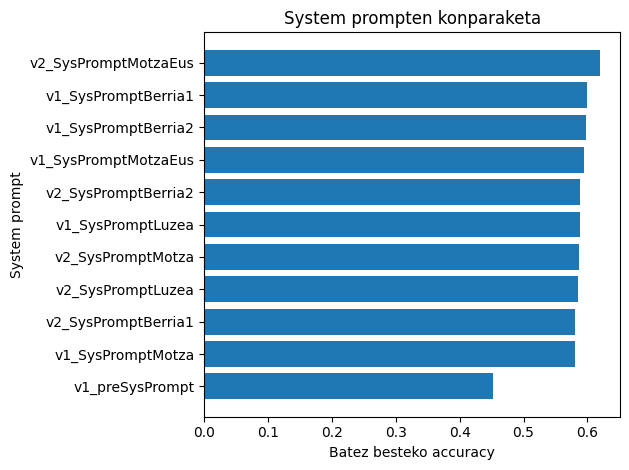

Laburpen azkarra:
System prompta
  Accuracy altuena: v2_SysPromptMotzaEus | mean_accuracy=0.620 | mean_time=0.292
  Egonkorrena: v2_SysPromptMotzaEus | stability_score=0.507 | std_accuracy=0.113


In [36]:
system_prompt_summary = summarize_config(df_analysis, "system_prompt")

print(f"Konparaketarako erabilitako iturburuko zutabea: {system_prompt_source_col}")
display(system_prompt_summary)

plt.figure()
plt.barh(system_prompt_summary["system_prompt"].astype(str), system_prompt_summary["mean_accuracy"])
plt.xlabel("Batez besteko accuracy")
plt.ylabel("System prompt")
plt.title("System prompten konparaketa")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Laburpen azkarra:")
print_best_from_summary("System prompta", system_prompt_summary, "system_prompt")


## 6. Euskarazko datuen eragina: Llama vs Latxa eta Salamandra


In [37]:
df_eu_effect = df_analysis[
    df_analysis["model_family"].isin(["Llama", "Latxa", "Salamandra"])
].copy()

eu_effect_general = summarize_config(df_eu_effect, "euskararen_eragina_taldea")
eu_effect_family = summarize_config(df_eu_effect, "model_family")
eu_effect_by_size = summarize_config(df_eu_effect, ["model_size_group", "euskararen_eragina_taldea", "model_family"])
eu_effect_by_size_quant = summarize_config(
    df_eu_effect,
    ["model_size_group", "quantization", "euskararen_eragina_taldea", "model_family"]
)

print("Euskara esplizitua duten ereduen eta eredu orokorren arteko konparazio orokorra:")
display(eu_effect_general)

print("Familien arteko konparazioa:")
display(eu_effect_family)

print("Tamainaren arabera banatutako konparazioa:")
display(eu_effect_by_size)

print("Tamaina eta kuantizazioaren arabera banatutako konparazioa:")
display(eu_effect_by_size_quant)


Euskara esplizitua duten ereduen eta eredu orokorren arteko konparazio orokorra:


,euskararen_eragina_taldea,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,euskara_esplizitua,0.609,0.136,0.251,0.816,0.381,0.512,1431,0.473,1.598
1,eredu_orokorra,0.542,0.076,0.291,0.754,0.461,0.468,864,0.466,1.177


Familien arteko konparazioa:


,model_family,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,Salamandra,0.616,0.095,0.298,0.758,0.164,0.178,297,0.520,3.749
1,Latxa,0.608,0.145,0.251,0.816,0.438,0.554,1134,0.463,1.386
2,Llama,0.542,0.076,0.291,0.754,0.461,0.468,864,0.466,1.177


Tamainaren arabera banatutako konparazioa:


,model_size_group,euskararen_eragina_taldea,model_family,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,txikia,euskara_esplizitua,Salamandra,0.616,0.095,0.298,0.758,0.164,0.178,297,0.520,3.749
1,handia,euskara_esplizitua,Latxa,0.610,0.135,0.271,0.786,0.744,0.650,567,0.476,0.820
2,txikia,euskara_esplizitua,Latxa,0.605,0.154,0.251,0.816,0.132,0.066,567,0.451,4.569
3,handia,eredu_orokorra,Llama,0.563,0.077,0.365,0.754,1.019,0.354,297,0.486,0.552
4,txikia,eredu_orokorra,Llama,0.531,0.074,0.291,0.709,0.168,0.136,567,0.457,3.159


Tamaina eta kuantizazioaren arabera banatutako konparazioa:


,model_size_group,quantization,euskararen_eragina_taldea,model_family,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,txikia,ez kuantizatua,euskara_esplizitua,Latxa,0.707,0.060,0.452,0.816,0.116,0.026,270,0.647,6.110
1,txikia,kuantizatua,euskara_esplizitua,Salamandra,0.616,0.095,0.298,0.758,0.164,0.178,297,0.520,3.749
2,handia,kuantizatua,euskara_esplizitua,Latxa,0.610,0.135,0.271,0.786,0.744,0.650,567,0.476,0.820
3,handia,kuantizatua,eredu_orokorra,Llama,0.563,0.077,0.365,0.754,1.019,0.354,297,0.486,0.552
4,txikia,ez kuantizatua,eredu_orokorra,Llama,0.550,0.059,0.301,0.709,0.119,0.029,270,0.491,4.639
5,txikia,kuantizatua,eredu_orokorra,Llama,0.514,0.081,0.291,0.669,0.213,0.175,297,0.433,2.410
6,txikia,kuantizatua,euskara_esplizitua,Latxa,0.513,0.156,0.251,0.776,0.148,0.085,297,0.357,3.472


## 7. Zero-shot vs few-shot


In [38]:
shot_group_summary = summarize_config(df_analysis, "shot_group")
shot_type_summary = summarize_config(df_analysis, "shot_type")
shot_by_model_size = summarize_config(df_analysis, ["model_size_group", "shot_group"])
shot_by_family = summarize_config(df_analysis, ["model_family", "shot_group"])

print("Zero-shot vs few-shot laburpena:")
display(shot_group_summary)

print("Zero-shot, few-shot-1 eta few-shot-2 bereizita:")
display(shot_type_summary)

print("Tamainaren arabera:")
display(shot_by_model_size)

print("Modelo-familiaren arabera:")
display(shot_by_family)

print("Laburpen azkarra:")
print_best_from_summary("Shot mota", shot_type_summary, "shot_type")
print_best_from_summary("Shot taldea", shot_group_summary, "shot_group")


Zero-shot vs few-shot laburpena:


,shot_group,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,zero-shot,0.591,0.118,0.271,0.789,0.342,0.447,765,0.473,1.726
1,few-shot,0.581,0.123,0.251,0.816,0.446,0.517,1530,0.457,1.303


Zero-shot, few-shot-1 eta few-shot-2 bereizita:


,shot_type,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,zero-shot,0.591,0.118,0.271,0.789,0.342,0.447,765,0.473,1.726
1,few-shot-1,0.587,0.120,0.251,0.816,0.411,0.471,765,0.467,1.428
2,few-shot-2,0.575,0.126,0.251,0.813,0.481,0.558,765,0.448,1.195


Tamainaren arabera:


,model_size_group,shot_group,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,handia,few-shot,0.598,0.117,0.274,0.786,0.913,0.579,576,0.481,0.654
1,txikia,zero-shot,0.593,0.112,0.291,0.789,0.133,0.134,477,0.481,4.476
2,handia,zero-shot,0.587,0.127,0.271,0.766,0.690,0.556,288,0.460,0.851
3,txikia,few-shot,0.570,0.126,0.251,0.816,0.163,0.121,954,0.444,3.489


Modelo-familiaren arabera:


,model_family,shot_group,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,Latxa,zero-shot,0.637,0.124,0.271,0.789,0.370,0.522,378,0.513,1.722
1,Salamandra,few-shot,0.623,0.093,0.361,0.758,0.171,0.174,198,0.530,3.643
2,Salamandra,zero-shot,0.602,0.099,0.298,0.719,0.151,0.185,99,0.503,3.989
3,Latxa,few-shot,0.593,0.152,0.251,0.816,0.473,0.567,756,0.441,1.255
4,Llama,few-shot,0.550,0.074,0.301,0.754,0.505,0.498,576,0.477,1.089
5,Llama,zero-shot,0.526,0.079,0.291,0.707,0.372,0.387,288,0.447,1.415


Laburpen azkarra:
Shot mota
  Accuracy altuena: zero-shot | mean_accuracy=0.591 | mean_time=0.342
  Egonkorrena: zero-shot | stability_score=0.473 | std_accuracy=0.118
Shot taldea
  Accuracy altuena: zero-shot | mean_accuracy=0.591 | mean_time=0.342
  Egonkorrena: zero-shot | stability_score=0.473 | std_accuracy=0.118


## 8. v1 vs v2


In [39]:
version_source_cols = [
    c for c in [
        "experiment", "system_prompt", "system_prompt_name", "system_prompt_type",
        "prompt_version", "version", "bertsioa"
    ]
    if c in df_analysis.columns
]

df_analysis["prompt_version_inferred"] = df_analysis.apply(
    lambda row: infer_v1_v2_from_row(row, version_source_cols),
    axis=1
)

df_v = df_analysis[df_analysis["prompt_version_inferred"].isin(["v1", "v2"])].copy()

print(f"Bertsioa inferitzeko erabilitako zutabeak: {version_source_cols}")
print("Identifikatutako bertsioen banaketa:")
display(
    df_analysis["prompt_version_inferred"]
    .value_counts()
    .rename_axis("bertsioa")
    .reset_index(name="n")
)

if df_v.empty:
    print("Ez da v1/v2 informaziorik automatikoki identifikatu.")
    print("Beharrezkoa bada, egiaztatu experiment edo system_prompt izenetan v1/v2 agertzen dela.")
else:
    version_summary = summarize_config(df_v, "prompt_version_inferred")
    version_by_model = summarize_config(df_v, ["prompt_version_inferred", "model"])
    version_by_system_prompt = summarize_config(df_v, ["prompt_version_inferred", "system_prompt"])

    print("v1 vs v2 laburpena:")
    display(version_summary)

    print("v1 vs v2 modeloka:")
    display(version_by_model)

    print("v1 vs v2 system promptaren arabera:")
    display(version_by_system_prompt)


Bertsioa inferitzeko erabilitako zutabeak: ['experiment', 'system_prompt']
Identifikatutako bertsioen banaketa:


,bertsioa,n
0,v1,1215
1,v2,1080


v1 vs v2 laburpena:


,prompt_version_inferred,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2,0.593,0.114,0.254,0.816,0.359,0.426,1080,0.479,1.652
1,v1,0.577,0.128,0.251,0.801,0.458,0.549,1215,0.449,1.259


v1 vs v2 modeloka:


,prompt_version_inferred,model,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v1,Latxa3.1-70B-v2,0.730,0.026,0.662,0.786,0.177,0.007,135,0.705,4.134
1,v2,latxa3.1-8B-fp16,0.720,0.045,0.559,0.816,0.111,0.022,135,0.676,6.519
2,v2,Latxa3.1-70B-v2,0.698,0.024,0.645,0.766,0.172,0.007,135,0.674,4.059
3,v1,latxa3.1-8B-fp16,0.694,0.070,0.452,0.801,0.121,0.029,135,0.624,5.736
4,v2,salamandra-7B,0.652,0.062,0.421,0.719,0.108,0.036,135,0.589,6.033
5,v1,salamandra-7B,0.586,0.107,0.298,0.758,0.211,0.228,162,0.478,2.775
6,v1,llama3.1-70B,0.568,0.076,0.365,0.754,1.139,0.419,162,0.492,0.499
7,v2,llama3.1-70B,0.557,0.078,0.455,0.717,0.876,0.171,135,0.479,0.636
8,v1,llama3.1-8B-fp16,0.552,0.067,0.301,0.709,0.124,0.031,135,0.485,4.451
9,v2,llama3.1-8B-fp16,0.549,0.050,0.431,0.686,0.113,0.025,135,0.499,4.845


v1 vs v2 system promptaren arabera:


,prompt_version_inferred,system_prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2,v2_SysPromptMotzaEus,0.620,0.113,0.267,0.756,0.292,0.324,216,0.507,2.125
1,v1,v1_SysPromptBerria1,0.600,0.102,0.251,0.757,0.431,0.497,216,0.499,1.394
2,v1,v1_SysPromptBerria2,0.597,0.105,0.251,0.766,0.483,0.577,216,0.492,1.236
3,v1,v1_SysPromptMotzaEus,0.594,0.139,0.251,0.781,0.333,0.393,216,0.455,1.783
4,v2,v2_SysPromptBerria2,0.589,0.103,0.268,0.753,0.433,0.504,216,0.486,1.361
5,v1,v1_SysPromptLuzea,0.588,0.121,0.251,0.784,0.407,0.477,216,0.467,1.446
6,v2,v2_SysPromptMotza,0.587,0.128,0.257,0.816,0.284,0.334,216,0.459,2.064
7,v2,v2_SysPromptLuzea,0.586,0.113,0.254,0.777,0.378,0.437,216,0.473,1.552
8,v2,v2_SysPromptBerria1,0.581,0.108,0.281,0.764,0.407,0.480,216,0.472,1.426
9,v1,v1_SysPromptMotza,0.581,0.140,0.251,0.801,0.317,0.384,216,0.441,1.833


## 9. Modeloaren tamaina: handiak vs txikiak


In [40]:
size_effect_summary = summarize_by(
    df_analysis[df_analysis["model_size_group"].isin(["txikia", "handia"])],
    "model_size_group"
)

size_effect_by_family = summarize_by(
    df_analysis[df_analysis["model_size_group"].isin(["txikia", "handia"])],
    ["model_size_group", "model_family"]
)

print("Modelo txikien eta handien konparazio orokorra:")
display(size_effect_summary)

print("Modelo txikien eta handien konparazioa familiaka:")
display(size_effect_by_family)


Modelo txikien eta handien konparazio orokorra:


,model_size_group,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,handia,0.594,0.120,0.839,0.581,864
1,txikia,0.578,0.122,0.153,0.126,1431


Modelo txikien eta handien konparazioa familiaka:


,model_size_group,model_family,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,txikia,Salamandra,0.616,0.095,0.164,0.178,297
1,handia,Latxa,0.610,0.135,0.744,0.650,567
2,txikia,Latxa,0.605,0.154,0.132,0.066,567
3,handia,Llama,0.563,0.077,1.019,0.354,297
4,txikia,Llama,0.531,0.074,0.168,0.136,567


## 10. Kuantizazioaren eragina


In [41]:
# Kuantizatuak vs kuantizatu gabeak: bakarrik modelo-base bereko bikoteak
valid_quant_pairs = (
    df_analysis
    .groupby("model_base")["is_quantized"]
    .nunique()
)
valid_quant_pairs = valid_quant_pairs[valid_quant_pairs == 2].index

df_quant_same_size = df_analysis[df_analysis["model_base"].isin(valid_quant_pairs)].copy()

quant_same_size_summary = summarize_by(
    df_quant_same_size,
    ["model_base", "model_family", "model_size_group", "model", "quantization", "quantization_type"]
)

quant_pair_effect = build_quantization_pair_effect(df_quant_same_size)

print("Kuantizatuak vs kuantizatu gabeak, tamaina bereko bikoteetan:")
display(quant_same_size_summary)

print("Kuantizazioaren diferentzia bikoteka:")
display(quant_pair_effect)

# Kuantizatuak vs kuantizatu gabeak: ikuspegi orokorra, Salamandra kanpoan utzita
df_quant_general = df_analysis[
    df_analysis["model_family"].isin(["Latxa", "Llama"])
].copy()

quant_general_summary = summarize_by(df_quant_general, "quantization")
quant_general_by_type = summarize_by(df_quant_general, "quantization_type")
quant_general_by_size = summarize_by(df_quant_general, ["model_size_group", "quantization"])
quant_general_by_family = summarize_by(df_quant_general, ["model_family", "quantization"])

print("Kuantizatuak eta kuantizatu gabeak orokorrean, Salamandra kanpoan utzita:")
display(quant_general_summary)

print("Kuantizazio motaren arabera:")
display(quant_general_by_type)

print("Tamainaren eta kuantizazioaren arabera:")
display(quant_general_by_size)

print("Familia eta kuantizazioaren arabera:")
display(quant_general_by_family)


Kuantizatuak vs kuantizatu gabeak, tamaina bereko bikoteetan:


,model_base,model_family,model_size_group,model,quantization,quantization_type,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,Latxa3.1-8B,Latxa,txikia,latxa3.1-8B-fp16,ez kuantizatua,ez kuantizatua,0.707,0.060,0.116,0.026,270
1,Llama3.1-8B,Llama,txikia,llama3.1-8B-fp16,ez kuantizatua,ez kuantizatua,0.550,0.059,0.119,0.029,270
2,Llama3.1-8B,Llama,txikia,llama3.1-8B,kuantizatua,kuantizatua,0.514,0.081,0.213,0.175,297
3,Latxa3.1-8B,Latxa,txikia,latxa3.1-8B,kuantizatua,kuantizatua,0.513,0.156,0.148,0.085,297


Kuantizazioaren diferentzia bikoteka:


,model_base,model_kuantizatua,kuantizazio_mota,model_ez kuantizatua,model_family,model_size_group,accuracy_kuantizatua,accuracy_ez kuantizatua,accuracy_diff_kuantizatua_minus_gabea,time_kuantizatua,time_ez kuantizatua,time_diff_kuantizatua_minus_gabea,n_runs_kuantizatua,n_runs_ez kuantizatua
0,Latxa3.1-8B,latxa3.1-8B,kuantizatua,latxa3.1-8B-fp16,Latxa,txikia,0.513,0.707,-0.194,0.148,0.116,0.032,297,270
1,Llama3.1-8B,llama3.1-8B,kuantizatua,llama3.1-8B-fp16,Llama,txikia,0.514,0.550,-0.037,0.213,0.119,0.094,297,270


Kuantizatuak eta kuantizatu gabeak orokorrean, Salamandra kanpoan utzita:


...

,quantization_type,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,ez kuantizatua,0.629,0.098,0.117,0.028,540
1,kuantizatua,0.561,0.128,0.571,0.559,1458


Tamainaren eta kuantizazioaren arabera:


,model_size_group,quantization,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,txikia,ez kuantizatua,0.629,0.098,0.117,0.028,540
1,handia,kuantizatua,0.594,0.120,0.839,0.581,864
2,txikia,kuantizatua,0.513,0.124,0.180,0.141,594


Familia eta kuantizazioaren arabera:


,model_family,quantization,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,Latxa,ez kuantizatua,0.707,0.060,0.116,0.026,270
1,Latxa,kuantizatua,0.577,0.150,0.539,0.600,864
2,Llama,ez kuantizatua,0.550,0.059,0.119,0.029,270
3,Llama,kuantizatua,0.538,0.083,0.616,0.491,594


## 11. Latxa vs Llama


In [42]:
df_latxa_llama = df_analysis[df_analysis["model_family"].isin(["Latxa", "Llama"])].copy()

latxa_llama_summary = summarize_by(df_latxa_llama, "model_family")
latxa_llama_by_size = summarize_by(df_latxa_llama, ["model_size_group", "model_family"])
latxa_llama_by_size_quant = summarize_by(df_latxa_llama, ["model_size_group", "quantization", "model_family"])
latxa_llama_by_size_quant_type = summarize_by(
    df_latxa_llama,
    ["model_size_group", "quantization_type", "model_family"]
)

print("Latxa eta Llama familien konparazio orokorra:")
display(latxa_llama_summary)

print("Latxa eta Llama tamainaren arabera:")
display(latxa_llama_by_size)

print("Latxa eta Llama tamaina + kuantizazioaren arabera:")
display(latxa_llama_by_size_quant)

print("Latxa eta Llama tamaina + kuantizazio motaren arabera:")
display(latxa_llama_by_size_quant_type)


Latxa eta Llama familien konparazio orokorra:


,model_family,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,Latxa,0.608,0.145,0.438,0.554,1134
1,Llama,0.542,0.076,0.461,0.468,864


Latxa eta Llama tamainaren arabera:


,model_size_group,model_family,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,handia,Latxa,0.610,0.135,0.744,0.650,567
1,txikia,Latxa,0.605,0.154,0.132,0.066,567
2,handia,Llama,0.563,0.077,1.019,0.354,297
3,txikia,Llama,0.531,0.074,0.168,0.136,567


Latxa eta Llama tamaina + kuantizazioaren arabera:


,model_size_group,quantization,model_family,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,txikia,ez kuantizatua,Latxa,0.707,0.060,0.116,0.026,270
1,handia,kuantizatua,Latxa,0.610,0.135,0.744,0.650,567
2,handia,kuantizatua,Llama,0.563,0.077,1.019,0.354,297
3,txikia,ez kuantizatua,Llama,0.550,0.059,0.119,0.029,270
4,txikia,kuantizatua,Llama,0.514,0.081,0.213,0.175,297
5,txikia,kuantizatua,Latxa,0.513,0.156,0.148,0.085,297


Latxa eta Llama tamaina + kuantizazio motaren arabera:


,model_size_group,quantization_type,model_family,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,txikia,ez kuantizatua,Latxa,0.707,0.060,0.116,0.026,270
1,handia,kuantizatua,Latxa,0.610,0.135,0.744,0.650,567
2,handia,kuantizatua,Llama,0.563,0.077,1.019,0.354,297
3,txikia,ez kuantizatua,Llama,0.550,0.059,0.119,0.029,270
4,txikia,kuantizatua,Llama,0.514,0.081,0.213,0.175,297
5,txikia,kuantizatua,Latxa,0.513,0.156,0.148,0.085,297


## 12. Tamaina antzekoen arteko konparazioa


In [43]:
small_similar_models = summarize_by(
    df_analysis[
        (df_analysis["model_size_group"] == "txikia") &
        (df_analysis["model_family"].isin(["Latxa", "Llama", "Salamandra"]))
    ],
    ["model_family", "model", "quantization", "quantization_type"]
)

large_similar_models = summarize_by(
    df_analysis[
        (df_analysis["model_size_group"] == "handia") &
        (df_analysis["model_family"].isin(["Latxa", "Llama"]))
    ],
    ["model_family", "model", "quantization", "quantization_type"]
)

print("Tamaina antzekoak: modelo txikiak")
display(small_similar_models)

print("Tamaina antzekoak: 70B modeloak")
display(large_similar_models)


Tamaina antzekoak: modelo txikiak


,model_family,model,quantization,quantization_type,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,Latxa,latxa3.1-8B-fp16,ez kuantizatua,ez kuantizatua,0.707,0.060,0.116,0.026,270
1,Salamandra,salamandra-7B,kuantizatua,kuantizatua,0.616,0.095,0.164,0.178,297
2,Llama,llama3.1-8B-fp16,ez kuantizatua,ez kuantizatua,0.550,0.059,0.119,0.029,270
3,Llama,llama3.1-8B,kuantizatua,kuantizatua,0.514,0.081,0.213,0.175,297
4,Latxa,latxa3.1-8B,kuantizatua,kuantizatua,0.513,0.156,0.148,0.085,297


Tamaina antzekoak: 70B modeloak


,model_family,model,quantization,quantization_type,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,Latxa,Latxa3.1-70B-v2,kuantizatua,kuantizatua,0.714,0.030,0.174,0.007,270
1,Llama,llama3.1-70B,kuantizatua,kuantizatua,0.563,0.077,1.019,0.354,297
2,Latxa,latxa3.1-70B,kuantizatua,kuantizatua,0.516,0.122,1.262,0.492,297


## 13. Accuracy Froga eta shot motaren arabera


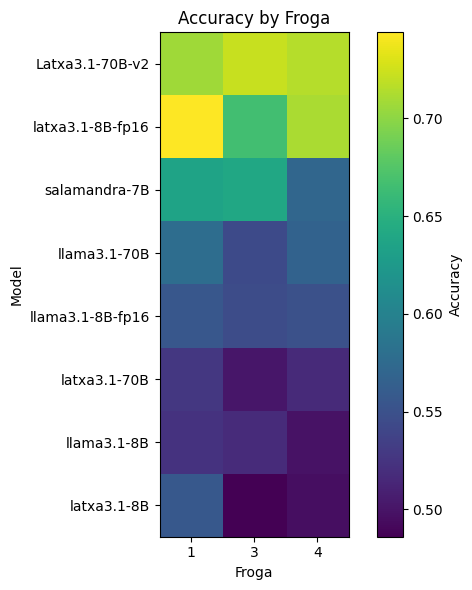

Accuracy froga bakoitzerako:


Froga,1,3,4
model,,,
Latxa3.1-70B-v2,0.707,0.722,0.715
latxa3.1-8B-fp16,0.744,0.666,0.711
salamandra-7B,0.636,0.640,0.571
llama3.1-70B,0.578,0.544,0.567
llama3.1-8B-fp16,0.556,0.546,0.550
latxa3.1-70B,0.528,0.502,0.517
llama3.1-8B,0.524,0.518,0.499
latxa3.1-8B,0.557,0.486,0.496


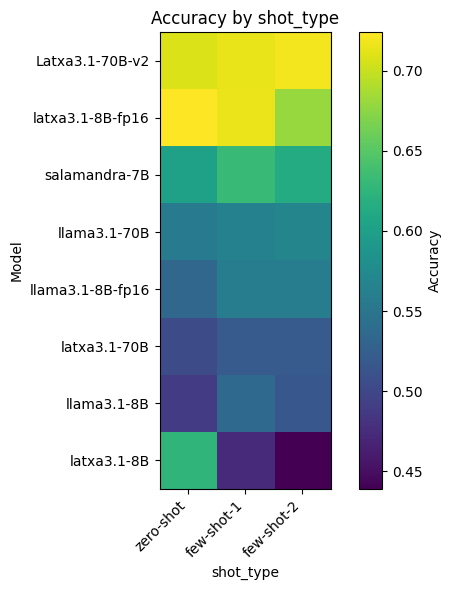

Accuracy shot mota bakoitzerako:


shot_type,zero-shot,few-shot-1,few-shot-2
model,,,
Latxa3.1-70B-v2,0.709,0.715,0.719
latxa3.1-8B-fp16,0.724,0.716,0.680
salamandra-7B,0.602,0.631,0.614
llama3.1-70B,0.557,0.564,0.569
llama3.1-8B-fp16,0.533,0.560,0.559
latxa3.1-70B,0.505,0.521,0.521
llama3.1-8B,0.489,0.536,0.516
latxa3.1-8B,0.626,0.474,0.439


In [44]:
pivot_accuracy_froga = build_pivot_model_froga(df_analysis, ACCURACY_COL)

plt.figure(figsize=(8, 6))
im = plt.imshow(pivot_accuracy_froga.values)
plt.title("Accuracy by Froga")
plt.xlabel("Froga")
plt.ylabel("Model")
plt.xticks(range(len(pivot_accuracy_froga.columns)), pivot_accuracy_froga.columns)
plt.yticks(range(len(pivot_accuracy_froga.index)), pivot_accuracy_froga.index)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Accuracy")
plt.tight_layout()
plt.show()

print("Accuracy froga bakoitzerako:")
display(pivot_accuracy_froga)

pivot_accuracy_shot = build_pivot_model_shot(df_analysis, ACCURACY_COL)

plt.figure(figsize=(8, 6))
im = plt.imshow(pivot_accuracy_shot.values)
plt.title("Accuracy by shot_type")
plt.xlabel("shot_type")
plt.ylabel("Model")
plt.xticks(range(len(pivot_accuracy_shot.columns)), pivot_accuracy_shot.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot_accuracy_shot.index)), pivot_accuracy_shot.index)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Accuracy")
plt.tight_layout()
plt.show()

print("Accuracy shot mota bakoitzerako:")
display(pivot_accuracy_shot)


## 14. Paretoak: accuracy eta exekuzio-denbora


In [58]:
# Quitar outlier extremo para el Pareto
pareto_df = df_analysis[
    ~(
        (df_analysis["experiment"] == "v1_preSysPrompt") &
        (df_analysis["model"] == "latxa3.1-70B") &
        (df_analysis["shot_type"] == "zero-shot") &
        (df_analysis["Froga"] == 4) &
        (df_analysis["Prompt"] == 2) &
        (df_analysis["Avg_exec_time"] > 6)
    )
].copy()

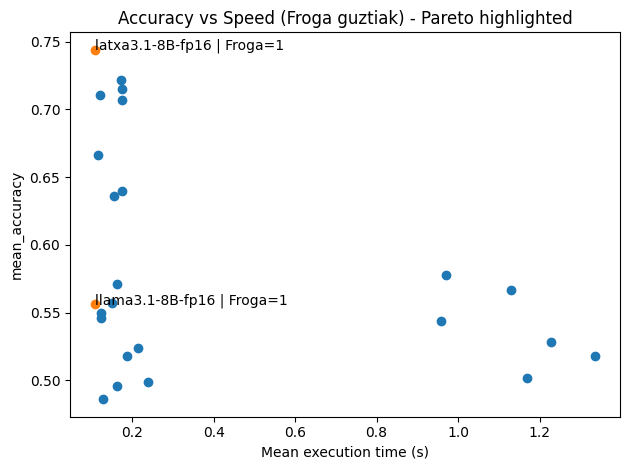

Froga mailako Pareto puntuak:


,Froga,model,mean_time,mean_accuracy,n_runs
6,1,llama3.1-8B-fp16,0.109,0.556,90
3,1,latxa3.1-8B-fp16,0.110,0.744,90


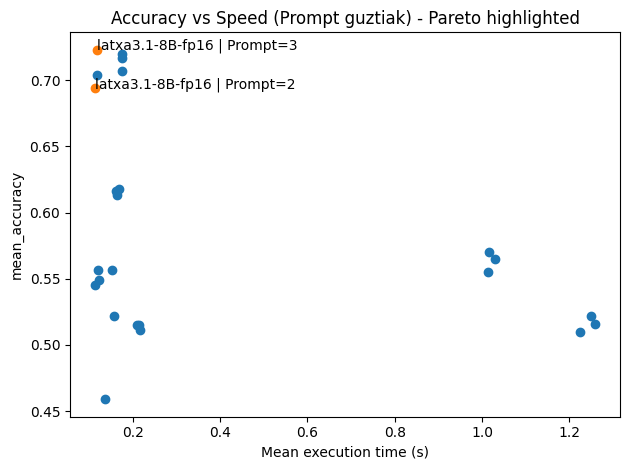

Prompt mailako Pareto puntuak:


,Prompt,model,mean_time,mean_accuracy,n_runs
11,2,latxa3.1-8B-fp16,0.113,0.694,90
19,3,latxa3.1-8B-fp16,0.117,0.723,90


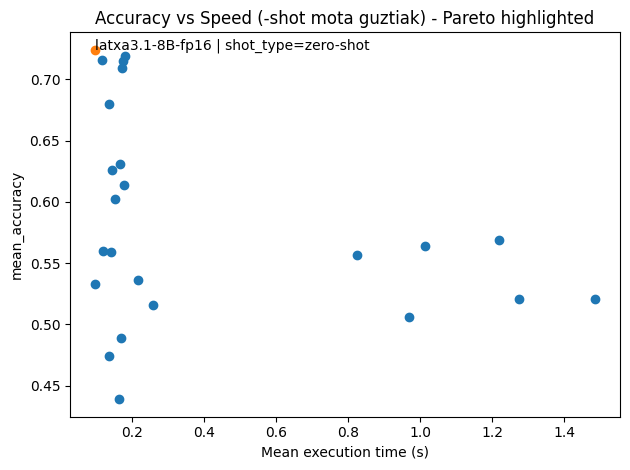

Shot mailako Pareto puntuak:


,shot_type,model,mean_time,mean_accuracy,n_runs
19,zero-shot,latxa3.1-8B-fp16,0.096,0.724,90


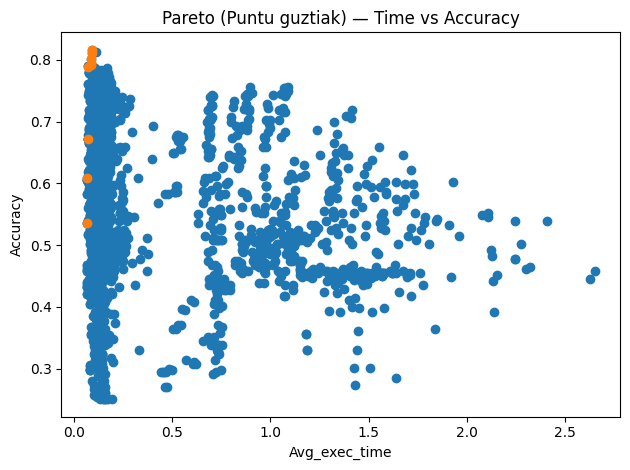

Puntu guztien Pareto taula:


,experiment,model,shot_type,Froga,Prompt,Accuracy,Avg_exec_time
0,v2_SysPromptMotzaEus,salamandra-7B,zero-shot,3,2,0.535,0.064
4,v2_SysPromptMotzaEus,salamandra-7B,zero-shot,1,2,0.608,0.065
25,v2_SysPromptMotzaEus,salamandra-7B,few-shot-1,1,2,0.672,0.070
30,v1_SysPromptMotza,latxa3.1-8B-fp16,zero-shot,4,2,0.789,0.070
141,v2_SysPromptMotza,latxa3.1-8B-fp16,few-shot-1,1,2,0.791,0.084
158,v2_SysPromptMotza,latxa3.1-8B-fp16,few-shot-1,1,3,0.794,0.085
185,v1_SysPromptMotza,latxa3.1-8B-fp16,few-shot-1,1,3,0.801,0.087
230,v2_SysPromptMotza,latxa3.1-8B-fp16,few-shot-2,1,2,0.811,0.091
264,v2_SysPromptMotza,latxa3.1-8B-fp16,few-shot-1,4,3,0.816,0.093


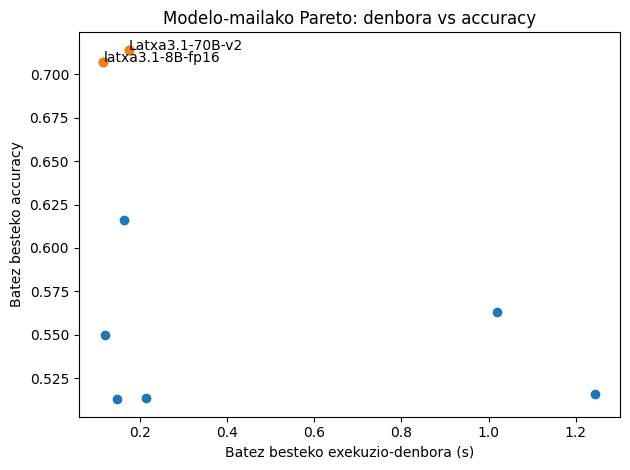

Modelo-mailako Pareto:


,model,model_family,model_size_group,quantization,quantization_type,mean_accuracy,std_accuracy,mean_time,std_time,n_runs
0,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,0.707,0.060,0.116,0.026,270
1,Latxa3.1-70B-v2,Latxa,handia,kuantizatua,kuantizatua,0.714,0.030,0.174,0.007,270


In [60]:
# Pareto: Froga
froga_summary = make_group_summary(pareto_df, "Froga")
_fo_all, froga_pareto = plot_all_groups_with_pareto(
    summary_df=froga_summary,
    group_col="Froga",
    quality_col="mean_accuracy",
    title="Accuracy vs Speed (Froga guztiak) - Pareto highlighted",
    label_pareto=True
)

print("Froga mailako Pareto puntuak:")
display(froga_pareto.sort_values(["mean_time"]).head(20))

# Pareto: Prompt
prompt_summary = make_group_summary(pareto_df, "Prompt")
_pr_all, prompt_pareto = plot_all_groups_with_pareto(
    summary_df=prompt_summary,
    group_col="Prompt",
    quality_col="mean_accuracy",
    title="Accuracy vs Speed (Prompt guztiak) - Pareto highlighted",
    label_pareto=True
)

print("Prompt mailako Pareto puntuak:")
display(prompt_pareto.sort_values(["mean_time"]).head(20))

# Pareto: shot_type
shot_summary = make_group_summary(pareto_df, "shot_type")
_sh_all, shot_pareto = plot_all_groups_with_pareto(
    summary_df=shot_summary,
    group_col="shot_type",
    quality_col="mean_accuracy",
    title="Accuracy vs Speed (-shot mota guztiak) - Pareto highlighted",
    label_pareto=True
)

print("Shot mailako Pareto puntuak:")
display(shot_pareto.sort_values(["mean_time"]).head(20))

# Pareto: puntu guztiak
pareto_all_accuracy = pareto_frontier_2d_all_points(
    pareto_df,
    time_col="Avg_exec_time",
    quality_col=ACCURACY_COL
)

plot_all_points_with_pareto(
    df_in=pareto_df.dropna(subset=["Avg_exec_time", ACCURACY_COL]),
    pareto_df=pareto_all_accuracy,
    time_col="Avg_exec_time",
    quality_col=ACCURACY_COL,
    title="Pareto (Puntu guztiak) — Time vs Accuracy"
)

pareto_cols = [
    "experiment", "model", "shot_type", "Froga", "Prompt",
    ACCURACY_COL, "Avg_exec_time"
]
print("Puntu guztien Pareto taula:")
display(safe_display_cols(pareto_all_accuracy, pareto_cols).head(50))

# Modelo-mailako Pareto
model_level_summary = summarize_by(
    pareto_df,
    ["model", "model_family", "model_size_group", "quantization", "quantization_type"]
)

pareto_model_mask = pareto_mask(
    model_level_summary,
    time_col="mean_time",
    quality_col="mean_accuracy"
)
pareto_model_summary = model_level_summary[pareto_model_mask].sort_values("mean_time").reset_index(drop=True)

plt.figure()
plt.scatter(model_level_summary["mean_time"], model_level_summary["mean_accuracy"])
plt.scatter(pareto_model_summary["mean_time"], pareto_model_summary["mean_accuracy"])

for _, r in pareto_model_summary.iterrows():
    plt.text(r["mean_time"], r["mean_accuracy"], r["model"])

plt.xlabel("Batez besteko exekuzio-denbora (s)")
plt.ylabel("Batez besteko accuracy")
plt.title("Modelo-mailako Pareto: denbora vs accuracy")
plt.tight_layout()
plt.show()

print("Modelo-mailako Pareto:")
display(pareto_model_summary)


## 15. Best absolute, azkarrena eta efficiency


In [46]:
best_accuracy_row = df_analysis.loc[df_analysis[ACCURACY_COL].idxmax()]
fastest_row = df_analysis.loc[df_analysis["Avg_exec_time"].idxmin()]

df_analysis = df_analysis.copy()
df_analysis["efficiency_accuracy"] = np.where(
    df_analysis["Avg_exec_time"] > 0,
    df_analysis[ACCURACY_COL] / df_analysis["Avg_exec_time"],
    np.nan
)
best_eff_accuracy = df_analysis.loc[df_analysis["efficiency_accuracy"].idxmax()]

main_cols = [
    "experiment", "model", "model_family", "model_size_group",
    "quantization", "quantization_type",
    "shot_type", "Froga", "Prompt",
    ACCURACY_COL, "Avg_exec_time", "efficiency_accuracy"
]

print("Accuracy maximo absolutua:")
display(safe_display_cols(best_accuracy_row.to_frame().T, main_cols))

print("Exekuzio-denbora laburrena:")
display(safe_display_cols(fastest_row.to_frame().T, main_cols))

print("Accuracy/denbora ratio onena:")
display(safe_display_cols(best_eff_accuracy.to_frame().T, main_cols))

print("Top 10 accuracy:")
display(
    safe_display_cols(
        df_analysis.sort_values(ACCURACY_COL, ascending=False).head(10),
        main_cols
    )
)


Accuracy maximo absolutua:


,experiment,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,Accuracy,Avg_exec_time
3206,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,4,3,0.816,0.093


Exekuzio-denbora laburrena:


,experiment,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,Accuracy,Avg_exec_time
3901,v2_SysPromptMotzaEus,salamandra-7B,Salamandra,txikia,kuantizatua,kuantizatua,zero-shot,3,2,0.535,0.064


Accuracy/denbora ratio onena:


,experiment,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,Accuracy,Avg_exec_time,efficiency_accuracy
1405,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.070,11.198


Top 10 accuracy:


,experiment,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,Accuracy,Avg_exec_time,efficiency_accuracy
3206,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,4,3,0.816,0.093,8.785
3330,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-2,4,3,0.813,0.110,7.384
3317,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-2,1,2,0.811,0.091,8.892
1146,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,3,0.801,0.087,9.210
3194,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,3,0.794,0.085,9.368
3193,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,2,0.791,0.084,9.462
1405,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.070,11.198
3453,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,zero-shot,4,2,0.789,0.071,11.181
3192,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,1,0.787,0.087,9.097
1144,v1_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,1,1,0.787,0.086,9.128


## 16. Laburpen automatikoa: emaitza nagusiak


In [47]:
print_best_from_summary("Modeloa", model_overall_summary, "model")
print_best_from_summary("System prompta", system_prompt_summary, "system_prompt")
print_best_from_summary("Shot mota", shot_type_summary, "shot_type")
print_best_from_summary("Shot taldea", shot_group_summary, "shot_group")
print_best_from_summary("Froga", dimension_summaries.get("Froga", pd.DataFrame()), "Froga")
print_best_from_summary("Prompt", dimension_summaries.get("Prompt", pd.DataFrame()), "Prompt")

print("\nKonbinazio onena accuracy-ren arabera:")
display(combination_summary.head(1))

print("\nParetoan gehien agertzen diren esperimentuak:")
display(pareto_all_accuracy["experiment"].value_counts().rename_axis("experiment").reset_index(name="n"))

print("\nParetoan gehien agertzen diren modeloak:")
display(pareto_all_accuracy["model"].value_counts().rename_axis("model").reset_index(name="n"))


Modeloa
  Accuracy altuena: Latxa3.1-70B-v2 | mean_accuracy=0.714 | mean_time=0.174
  Egonkorrena: Latxa3.1-70B-v2 | stability_score=0.685 | std_accuracy=0.030
System prompta
  Accuracy altuena: v2_SysPromptMotzaEus | mean_accuracy=0.620 | mean_time=0.292
  Egonkorrena: v2_SysPromptMotzaEus | stability_score=0.507 | std_accuracy=0.113
Shot mota
  Accuracy altuena: zero-shot | mean_accuracy=0.591 | mean_time=0.342
  Egonkorrena: zero-shot | stability_score=0.473 | std_accuracy=0.118
Shot taldea
  Accuracy altuena: zero-shot | mean_accuracy=0.591 | mean_time=0.342
  Egonkorrena: zero-shot | stability_score=0.473 | std_accuracy=0.118
Froga
  Accuracy altuena: 1.0 | mean_accuracy=0.601 | mean_time=0.398
  Egonkorrena: 1.0 | stability_score=0.481 | std_accuracy=0.120
Prompt
  Accuracy altuena: 3.0 | mean_accuracy=0.594 | mean_time=0.412
  Egonkorrena: 3.0 | stability_score=0.476 | std_accuracy=0.117

Konbinazio onena accuracy-ren arabera:


,system_prompt,model,model_family,model_size_group,quantization,quantization_type,shot_type,Froga,Prompt,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_time,std_time,n_runs,stability_score,efficiency_score
0,v2_SysPromptMotza,latxa3.1-8B-fp16,Latxa,txikia,ez kuantizatua,ez kuantizatua,few-shot-1,4,3,0.816,0.000,0.816,0.816,0.093,0.000,1,0.816,8.785



Paretoan gehien agertzen diren esperimentuak:


,experiment,n
0,v2_SysPromptMotza,4
1,v2_SysPromptMotzaEus,3
2,v1_SysPromptMotza,2



Paretoan gehien agertzen diren modeloak:


,model,n
0,latxa3.1-8B-fp16,6
1,salamandra-7B,3


## 17. Outlierrak


In [48]:
# Denboraren outlierrak
lower_t, upper_t = detect_outliers_iqr(df_analysis["Avg_exec_time"])

time_outliers = df_analysis[
    (df_analysis["Avg_exec_time"] < lower_t) |
    (df_analysis["Avg_exec_time"] > upper_t)
].copy()

# Accuracy-ren outlierrak
lower_a, upper_a = detect_outliers_iqr(df_analysis[ACCURACY_COL])

accuracy_outliers = df_analysis[
    (df_analysis[ACCURACY_COL] < lower_a) |
    (df_analysis[ACCURACY_COL] > upper_a)
].copy()

outlier_cols = [
    "experiment", "model", "shot_type", "Froga", "Prompt",
    ACCURACY_COL, "Avg_exec_time"
]

print(f"Denboraren outlier mugak: lower={lower_t:.3f}, upper={upper_t:.3f}")
print("Denboraren outlierrak:")
display(
    safe_display_cols(
        time_outliers.sort_values("Avg_exec_time", ascending=False).head(20),
        outlier_cols
    )
)

print(f"Accuracy-ren outlier mugak: lower={lower_a:.3f}, upper={upper_a:.3f}")
print("Accuracy-ren outlierrak:")
display(
    safe_display_cols(
        accuracy_outliers.sort_values(ACCURACY_COL, ascending=False).head(20),
        outlier_cols
    )
)

print("Denboraren outlierrak modeloka:")
display(time_outliers["model"].value_counts().rename_axis("model").reset_index(name="n"))

print("Denboraren outlierrak shot motaren arabera:")
display(time_outliers["shot_type"].value_counts().rename_axis("shot_type").reset_index(name="n"))

print("Denboraren outlierrak esperimentuka:")
display(time_outliers["experiment"].value_counts().rename_axis("experiment").reset_index(name="n"))


Denboraren outlier mugak: lower=-0.750, upper=1.556
Denboraren outlierrak:


,experiment,model,shot_type,Froga,Prompt,Accuracy,Avg_exec_time
1997,v1_preSysPrompt,latxa3.1-70B,zero-shot,4,2,0.421,6.546
1933,v1_preSysPrompt,latxa3.1-70B,few-shot-2,4,2,0.458,2.651
1934,v1_preSysPrompt,latxa3.1-70B,few-shot-2,4,3,0.445,2.629
1960,v1_preSysPrompt,llama3.1-70B,few-shot-2,4,1,0.538,2.407
569,v1_SysPromptBerria2,llama3.1-70B,few-shot-2,4,2,0.465,2.320
1868,v1_preSysPrompt,latxa3.1-70B,few-shot-1,4,1,0.462,2.303
1962,v1_preSysPrompt,llama3.1-70B,few-shot-2,4,3,0.502,2.276
1924,v1_preSysPrompt,latxa3.1-70B,few-shot-2,1,1,0.478,2.247
1932,v1_preSysPrompt,latxa3.1-70B,few-shot-2,4,1,0.478,2.245
1896,v1_preSysPrompt,llama3.1-70B,few-shot-1,4,1,0.538,2.244


Accuracy-ren outlier mugak: lower=0.212, upper=0.975
Accuracy-ren outlierrak:


,experiment,model,shot_type,Froga,Prompt,Accuracy,Avg_exec_time


Denboraren outlierrak modeloka:


,model,n
0,latxa3.1-70B,51
1,llama3.1-70B,29


Denboraren outlierrak shot motaren arabera:


,shot_type,n
0,few-shot-2,59
1,few-shot-1,13
2,zero-shot,8


Denboraren outlierrak esperimentuka:


,experiment,n
0,v1_preSysPrompt,28
1,v1_SysPromptBerria2,16
2,v1_SysPromptBerria1,12
3,v2_SysPromptBerria2,12
4,v1_SysPromptLuzea,6
5,v2_SysPromptBerria1,6


## 18 Emaitza hoberenak


In [52]:
df_test = df_analysis.copy()

# Zutabe erabilgarriak erakusteko
best_cols = [
    "experiment",
    "model",
    "shot_type",
    "Froga",
    "Prompt",
    ACCURACY_COL,
    "Avg_exec_time"
]

### Prompt / experiment bakoitzeko emaitzarik onena

In [55]:
best_by_experiment = (
    df_test
    .sort_values(
        [ACCURACY_COL, "Avg_exec_time"],
        ascending=[False, True]
    )
    .groupby("experiment", as_index=False)
    .first()
)

print("Experiment bakoitzeko emaitzarik onena:")
display(
    safe_display_cols(
        best_by_experiment,
        best_cols
    ).sort_values(ACCURACY_COL, ascending=False)
)



Experiment bakoitzeko emaitzarik onena:


,experiment,model,shot_type,Froga,Prompt,Accuracy,Avg_exec_time
9,v2_SysPromptMotza,latxa3.1-8B-fp16,few-shot-1,4,3,0.816,0.093
3,v1_SysPromptMotza,latxa3.1-8B-fp16,few-shot-1,1,3,0.801,0.087
2,v1_SysPromptLuzea,latxa3.1-8B-fp16,few-shot-2,1,3,0.784,0.135
4,v1_SysPromptMotzaEus,latxa3.1-8B-fp16,few-shot-1,1,2,0.781,0.094
8,v2_SysPromptLuzea,latxa3.1-8B-fp16,few-shot-1,1,2,0.777,0.106
1,v1_SysPromptBerria2,Latxa3.1-70B-v2,few-shot-2,3,3,0.766,0.185
6,v2_SysPromptBerria1,latxa3.1-8B-fp16,few-shot-1,1,2,0.764,0.118
0,v1_SysPromptBerria1,latxa3.1-8B-fp16,few-shot-1,1,2,0.757,0.121
10,v2_SysPromptMotzaEus,latxa3.1-70B,few-shot-1,4,1,0.756,0.896
7,v2_SysPromptBerria2,latxa3.1-8B-fp16,zero-shot,4,2,0.753,0.116


### Modelo bakoitzeko emaitzarik onena

In [56]:
best_by_model = (
    df_test
    .sort_values(
        [ACCURACY_COL, "Avg_exec_time"],
        ascending=[False, True]
    )
    .groupby("model", as_index=False)
    .first()
)

print("Modelo bakoitzeko emaitzarik onena:")
display(
    safe_display_cols(
        best_by_model,
        best_cols
    ).sort_values(ACCURACY_COL, ascending=False)
)

Modelo bakoitzeko emaitzarik onena:


,experiment,model,shot_type,Froga,Prompt,Accuracy,Avg_exec_time
3,v2_SysPromptMotza,latxa3.1-8B-fp16,few-shot-1,4,3,0.816,0.093
0,v1_SysPromptMotza,Latxa3.1-70B-v2,few-shot-2,4,3,0.786,0.170
2,v1_SysPromptLuzea,latxa3.1-8B,zero-shot,3,3,0.776,0.113
7,v1_SysPromptBerria2,salamandra-7B,few-shot-1,1,1,0.758,0.128
1,v2_SysPromptMotzaEus,latxa3.1-70B,few-shot-1,4,1,0.756,0.896
4,v1_SysPromptMotzaEus,llama3.1-70B,few-shot-2,1,1,0.754,1.072
6,v1_SysPromptMotza,llama3.1-8B-fp16,few-shot-2,4,3,0.709,0.146
5,v2_SysPromptBerria1,llama3.1-8B,few-shot-2,3,1,0.669,0.152
